In [4]:
from google.colab import files
# uploaded = files.upload()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pesticides_df = pd.read_excel('pesticidesData.xls', usecols=range(16))
df = pesticides_df.copy()
df.head()

,S.No.,R. No.,Date,Job No.,Firm Name,Brand Name,Comman Name,Formulation,Quantity (lit/kg),C & F\nValue,Ex.Rate (US$),Total Value (Rs.),Origin,Reg. No.,PSI,Category
0,1.0,2.0,"02-January,2017",C/PK/QC16015,Exin Chemicals,Xiaowang,Mesotrione + Atrazine,55% soluble concentration,16000.0,3.30,106.0,5596800.0,China,R-1912,NMCI,Herb.
1,2.0,2.0,"02-January,2017",C/S/PK/170059/16,New Agri Care,Deft,Metsulfuron Methyl,10% waightable powder,2000.0,3.37,106.0,714440.0,China,R-908,NMCI,Herb.
2,3.0,1.0,"02-January,2017",CU16119148,Tara Imperial Industries,NaN,Glyphosate,41% soluble liquid,32000.0,1.78,106.0,6037760.0,China,R-6945,CU,Herb.
3,4.0,4.0,"02-January,2017",CU16119110,Tara Imperial Industries,NaN,Metalaxyl + Mancozeb,72% waightable powder,15000.0,3.60,106.0,5724000.0,China,R-4982,CU,Fungicide
4,5.0,4.0,"03-January,2017",PK-130617/16,Sun Crop Pesticides,Truce Xtra,Mesotrione + Atrazine,88.8% weightable granulers,1000.0,8.50,106.0,901000.0,China,R-1983,NMCI,Herb.


In [7]:
df.columns = df.columns.str.strip().str.replace('\n', '').str.replace('  ', ' ')
print(df.columns.tolist())  # verify cleaned names


['S.No.', 'R. No.', 'Date', 'Job No.', 'Firm Name', 'Brand Name', 'Comman Name', 'Formulation', 'Quantity (lit/kg)', 'C & FValue', 'Ex.Rate (US$)', 'Total Value (Rs.)', 'Origin', 'Reg. No.', 'PSI', 'Category']


In [8]:
df['Total Value (Rs.)'] = df['Quantity (lit/kg)']*df['C & FValue']*df['Ex.Rate (US$)']

In [9]:
df.drop(columns=['S.No.','R. No.','Ex.Rate (US$)'],inplace=True)
df['Brand Name'].fillna("Form-16",inplace=True)

/tmp/ipython-input-1601225596.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Brand Name'].fillna("Form-16",inplace=True)


In [10]:
from dateutil import parser

def parse_messy_date(date_str):
    try:
        parsed_date = parser.parse(date_str, dayfirst=True, fuzzy=True)
        return parsed_date.strftime('%Y-%m-%d')
    except (ValueError, TypeError):
        return np.nan
df['Date'] = df['Date'].apply(parse_messy_date)

In [11]:
pd.set_option('display.max_rows', None)
df['Formulation'].value_counts()

,count
Formulation,
80% weightable granulers,133
25% waightable powder,129
15% waightable powder,67
72% waightable powder,64
70% waightable powder,52
75% soluble powder,49
20% soluble liquid,44
55% soluble concentration,41
55% soluble concentration,40


In [12]:
import re

# Regex to match either:
# 1. number (with optional %) at the start, then type
# 2. OR type at the start, number at the end
pattern = r"""
    ^\s*
    (?:
        (?P<Percentage1>\d+(?:\.\d+)?)       # number at start
        (?:%)?                               # optional %
        \s*(?P<Type1>.+)                     # type after number
    |
        (?P<Type2>[A-Za-z\s]+)               # type at start
        \s*(?P<Percentage2>\d+(?:\.\d+)?)    # number at end
    )
    \s*$
"""

extracted = df['Formulation'].str.extract(pattern, flags=re.VERBOSE)

df['Percentage'] = extracted['Percentage1'].combine_first(extracted['Percentage2'])
df['Type'] = extracted['Type1'].combine_first(extracted['Type2'])

df['Percentage'] = pd.to_numeric(df['Percentage'], errors='coerce')
df['Type'] = df['Type'].str.strip()

df.dropna(subset=['Percentage','Type'],inplace=True)

In [13]:
df.head(10)

,Date,Job No.,Firm Name,Brand Name,Comman Name,Formulation,Quantity (lit/kg),C & FValue,Total Value (Rs.),Origin,Reg. No.,PSI,Category,Percentage,Type
0,2017-01-02,C/PK/QC16015,Exin Chemicals,Xiaowang,Mesotrione + Atrazine,55% soluble concentration,16000.0,3.30,5596800.0,China,R-1912,NMCI,Herb.,55.0,soluble concentration
1,2017-01-02,C/S/PK/170059/16,New Agri Care,Deft,Metsulfuron Methyl,10% waightable powder,2000.0,3.37,714440.0,China,R-908,NMCI,Herb.,10.0,waightable powder
2,2017-01-02,CU16119148,Tara Imperial Industries,Form-16,Glyphosate,41% soluble liquid,32000.0,1.78,6037760.0,China,R-6945,CU,Herb.,41.0,soluble liquid
3,2017-01-02,CU16119110,Tara Imperial Industries,Form-16,Metalaxyl + Mancozeb,72% waightable powder,15000.0,3.60,5724000.0,China,R-4982,CU,Fungicide,72.0,waightable powder
4,2017-01-03,PK-130617/16,Sun Crop Pesticides,Truce Xtra,Mesotrione + Atrazine,88.8% weightable granulers,1000.0,8.50,901000.0,China,R-1983,NMCI,Herb.,88.8,weightable granulers
5,2017-01-03,CU16119088,Sino Pak Chemicals,Form-16,Trichlorfon,80% soluble powder,32000.0,2.50,8480000.0,China,R-6829,CU,Insect.,80.0,soluble powder
6,2017-01-03,BTIN/1247/16,Four Brothers Agri Service,Form-16,Clodinafop Propargyl,15% waightable powder,10000.0,10.45,11077000.0,India,R-5975,BALTIC,Herb.,15.0,waightable powder
7,2017-01-04,CU16119140,Sayban International,Form-16,Trichlorfon,80% soluble powder,16000.0,1.65,2798400.0,China,R-6613,CU,Insect.,80.0,soluble powder
8,2017-01-04,CU16129171,ICI Pakistan,Form-16,Trichlorfon,80% soluble powder,25344.0,4.15,11148825.6,China,R-5818,CU,Insect.,80.0,soluble powder
9,2017-01-04,CU16119029,Pak China Chemicals,Form-16,Aluminium Phosphide,56% Tablets,25032.0,3.85,10215559.2,China,R-3550,CU,Fumigant,56.0,Tablets


In [14]:
df['Percentage'].value_counts().sort_index(ascending=True)

,count
Percentage,
0.02,1
0.40,1
0.50,21
1.80,11
1.90,14
2.00,1
2.50,6
3.00,7
3.60,3


In [15]:
df['Type'].value_counts().sort_index(ascending=True)

,count
Type,
% emulsifier concentration,1
(ALP),6
(ALP) Tab,1
(ALP) Tablets,1
(g/l),4
(g/l) CS,2
(g/l) SE,1
(g/l) soluble concentration,3
(g/l) soluble liquid,2


In [16]:
df['Type'] = (
    df['Type']
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(r'[%()+/]', ' ', regex=True)
    .str.replace(r'[^A-Z0-9\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

replace_map = {
    'ALP': 'ALP TABLETS',
    'ALP TAB': 'ALP TABLETS',
    'TAB': 'ALP TABLETS',
    'TABLET': 'ALP TABLETS',
    'TABLETS': 'ALP TABLETS',
    'WP': 'WAIGHTABLE POWDER',
    'WDG 20 60': 'WDG',
    'WS': 'WATER SOLUBLE POWDER',
    'WSOLUBLE POWDER': 'WATER SOLUBLE POWDER',
    'SOLUBLE POWDER': 'WATER SOLUBLE POWDER',
    'SC': 'SOLUBLE CONCENTRATE',
    'OF': 'OIL FORMULATION',
    'OD': 'OIL DISPERSION',
    'EW': 'EMULSION, OIL IN WATER',
    'EC': 'EMULSIFIABLE CONCENTRATE',
    'EMULSIFIER CONCENTRATION': 'EMULSIFIABLE CONCENTRATE',
    'EMULSION CONCENTRATION': 'EMULSIFIABLE CONCENTRATE',
    'DF': 'DRY FLOWABLE',
    'ME': 'MICRO EMULSION',
    'G L CS': 'GRAMS PER LITRE SOLUBLE CONCENTRATE',
    'G L SOLUBLE CONCENTRATION': 'GRAMS PER LITRE SOLUBLE CONCENTRATE',
    'G L SOLUBLE LIQUID': 'GRAMS PER LITRE SOLUBLE LIQUID',
    'G L SE': 'GRAMS PER LITRE SUSPENSION EMULSION',
    'G/L': 'GRAMS PER LITRE',
    'GL': 'GRAMS PER LITRE',
    'G L': 'GRAMS PER LITRE',
    'SOLUBLE CONCENTRATION': 'SOLUBLE CONCENTRATE',
    'ZC': 'MIXED FORMULATION (ZC)',
    'AS': 'AQUEOUS SOLUTION',
    'SE': 'SUSPENSION EMULSION',
    'SG': 'SOLUBLE GRANULES',
    'KPP': 'KILOGRAMS PER PACK',
    'CF': 'CONTROL FORMULATION',
    'EO': 'EMULSION, OIL IN WATER',
    'G': 'GRAMS PER LITRE',
    'W W': 'WEIGHT BY WEIGHT',
    'W W PERCENTAGE': 'WEIGHT BY WEIGHT',
    '+2': '2% CHLOROPICRIN',
    '2': '2% CHLOROPICRIN',
    '2 PERCENT': '2% CHLOROPICRIN',
    '2 CHLOROPICRIN': '2% CHLOROPICRIN',
    'PLATES STRIPS': 'PLATES',
}

# Normalize using replacement dictionary
df['Type'] = df['Type'].replace(replace_map)
df['Type'].value_counts().sort_index(ascending=True)

,count
Type,
2% CHLOROPICRIN,9
ALP TABLETS,29
AQUEOUS SOLUTION,21
CONCENTRATE BAIT,1
CONTROL FORMULATION,3
DRY FLOWABLE,6
EMULSIFIABLE CONCENTRATE,215
"EMULSION, OIL IN WATER",5
FLOWABLE SUSPENSION,11


In [17]:
df = df.drop('Formulation', axis=1)

In [18]:
df = df.rename(columns={
    'Common Name': 'Composition'
})

In [19]:
df['Category'].value_counts()

,count
Category,
Herb.,500
Insect.,429
Fung.,274
Fungicide,202
Insect,79
Fumigant,31
Biological,21
Fum.,3
Insecticide,2


In [20]:
category_mapping = {
    'Herb.': 'Herbicide',
    'Fung.': 'Fungicide',
    'Insect.': 'Insecticide',
    'Insect': 'Insecticide',
    'Fumigation': 'Fumigant',
    'Fum.': 'Fumigant',
    'Acari': 'Acaricide',
    'Acaracide': 'Acaricide',
    'Acracide': 'Acaricide',
}

In [21]:
df['Category'] = df['Category'].replace(category_mapping)

In [22]:
df['Category'].value_counts()

,count
Category,
Insecticide,510
Herbicide,500
Fungicide,476
Fumigant,35
Biological,21
Acaricide,3


In [23]:
import re

def normalize_firm_name(name):
    if not isinstance(name, str):
        return ""

    name = name.upper()
    name = re.sub(r'[^\w\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()

    replacements = {
        'PRIVATE LIMITED': '', 'PVT LTD': '', 'LTD': '', 'LIMITED': '', 'PVT': '',
        'ENTERPRISES': 'ENTERPRISE',
        'ENTREPRENUER': 'ENTREPRENEUR',
        'ENTERPRENEUR': 'ENTREPRENEUR',
        'ENTREPRENEUR': 'ENTERPRISE',
        'CHEMCIALS': 'CHEMICALS',
        'CHEMICALES': 'CHEMICALS',
        'CHEMICALS': 'CHEMICAL',
        'PESTICIDES': 'PESTICIDE',
        'PESTISIDE': 'PESTICIDE',
        'SCIENCES': 'SCIENCE',
        'LIFESCIENCE': 'LIFE SCIENCE',
        'AGROSCIENCE': 'AGRO SCIENCE',
        'AGROSCIENCES': 'AGRO SCIENCE',
        'SERVICES': 'SERVICE',
        'DISTRIBUTERS': 'DISTRIBUTORS',
        'DISTRIBUTION': 'DISTRIBUTORS',
        'CENTER': 'CENTRE',
        'CORP': 'CORPORATION',
        'CORPORATIONORATION': 'CORPORATION',
        'ALNOOR': 'AL NOOR',
        'AGROTREE': 'AGRO TREE',
        'AGROCHINA': 'AGRO CHINA',
        'RICECO': 'RICE CO',
        'WELCOM AGRO': 'WELCOME AGRO',
        'WELCOME AGRO CHEMICAL': 'WELCOME AGRO',
        'WELCOME CHEMICAL': 'WELCOME AGRO',
        'WELCON AGRO CHEMICAL': 'WELCOME AGRO',
        'WELCON CHEMICAL': 'WELCOME AGRO',
        'WELCONE CHEMICAL': 'WELCOME AGRO',
        ' KARACHI': '',
        'PAKISTAN': '',
        'INDUSTRIES': '',
        'STEDECT': 'STEDEC',
        'CORPORATION': '',
        'FOR': '4',
        'R B': 'RB',
        'SERVICE': '',
        'SCIENCE': '',
        'BIOLOGIC AG': 'AGRI',
        'FOURBROTHERS': 'FOURBROTHER',
        'FMC': 'FM',
        'S ESSA': 'SESSA',
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    name = re.sub(r'\s+', ' ', name).strip()

    return name

df['Firm Name'] = df['Firm Name'].apply(normalize_firm_name)

In [24]:
manual_firm_map = {
    'ABDULLAH HASEEB': 'ABDULLAH HASEEB AGRO CHEMICAL',
    'AGGRIO':'AGGRIO CHEMICAL',
    'AGRI 4CE': 'AGRI 4CE CHEMICAL',
    'AGRO': 'AGRO TREE LIFE',
    'AGROW': 'AGROW MARK',
    'AJMA CHEM': 'AJMA CHEMICAL',
    'AGRO CHEMICAL': 'AL NOOR AGRO CHEMICAL',
    'ARYSTA LIFE SCIENE': 'ARYSTA LIFE',
    'AURIGA CHEMICAL ENTERPRISE': 'AURIGA CHEMICAL',
    'CAPRICORN': 'CAPRICORN ASSOCIATIONS',
    'COMMANDER AGRO CHEMICAL': 'COMMANDER AGRO',
    'DU PONT OPERATIONS': 'DUPONT',
    'DUPENT OPERATION': 'DUPONT',
    'FOURBROTHER AGRI': 'FOURBROTHER BIOLOGIC',
    'FOURBROTHERBIOLOGIC': 'FOURBROTHER BIOLOGIC',
    'HELB AGRO CHEMICAL': 'HELB AGRO',
    'HELB PESTICIDE CHEMICAL': 'HELB PESTICIDE',
    'HEXTAR CHEMICAL ENTERPRISE': 'HEXTAR CHEMICAL',
    'NAFEES ENTERPRENUER': 'NAFEES ENTERPRISE',
    'PRIME BIOLOGICAL': 'PRIME BIOLOGICAL ENTERPRISE',
}

manual_firm_map_normalized = {normalize_firm_name(k): v for k, v in manual_firm_map.items()}

df['Firm Name'] = df['Firm Name'].replace(manual_firm_map_normalized)


df['Firm Name'].value_counts().sort_index(ascending=True)

,count
Firm Name,
ABDULLAH HASEEB AGRO CHEMICAL,15
ADEEL PESTICIDE,1
AGGRIO CHEMICAL,6
AGRI 4CE CHEMICAL,15
AGRI INTERNATIONAL,2
AGRI TOP,3
AGRICA CHEMICAL,12
AGRIMORE,8
AGRINCHEM ENTERPRISE,4


In [25]:
df['Brand Name'].value_counts().sort_index(ascending=True)

,count
Brand Name,
Acelam,4
Acord,1
Acrid,1
Acrobat MZ,2
Actara,6
Actara ST,1
Adventure,1
Agroguard,1
Aiker,2


In [26]:
import pandas as pd

df['Brand Name'] = (
    df['Brand Name']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'[-_/]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

manual_map = {
    'Form 16': 'Form-16',
    'Ful Clear': 'Ful-Clear',
    'Ful Control': 'Ful-Control',
    'Ridomil Gold Mz': 'Ridomil Gold MZ',
    'Thiovet Jet': 'Thiovit Jet',
    'Kumulus Df': 'Kumulus-DF',
    'Kumulus D F': 'Kumulus-DF',
    'Liman Tian': 'Li Man Tian',
    'Hombre ': 'Hombre',
    'Defeater ': 'Defeater',
    'Sega Pest Clear': 'Sega',
    'Recado Xtra': 'Recado',
    'Hombre Excel': 'Hombre',
    'Double Star': 'Double',
    'Defeater Plus': 'Defeater',
    'Atlantis Super': 'Atlantis',
    'Actara St': 'Actara',
    'Segawin': 'Sega',
    'Romer': 'Romeo',
    'Core': 'Cure',
}
df['Brand Name'] = df['Brand Name'].replace(manual_map)
df['Brand Name'].value_counts().sort_index(ascending=True)

,count
Brand Name,
Acelam,4
Acord,1
Acrid,1
Acrobat Mz,2
Actara,7
Adventure,1
Agroguard,1
Aiker,2
Aimanli,1


In [27]:
df['Origin'].value_counts()

,count
Origin,
China,1039
India,297
Germany,59
USA,33
France,16
Indonesia,16
Denmark,15
Australia,13
Japan,12


In [28]:
origin_dict = {
    'Malysia': 'Malaysia',
    'England': 'UK',
    'Korea': 'South Korea',
    'Ausrtia': 'Austria',
    'Austalia': 'Australia',
}

df['Origin'].replace(origin_dict, inplace=True)
df['Origin'].value_counts()

/tmp/ipython-input-3762645648.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Origin'].replace(origin_dict, inplace=True)


,count
Origin,
China,1039
India,297
Germany,59
USA,33
France,16
Indonesia,16
Denmark,15
Australia,14
Japan,12


In [29]:
df['PSI'].value_counts()

,count
PSI,
CU,852
NMCI,458
BALTIC,83
Baltic,82
ICI,53
Cotecna,11
Japan,2
C.N,1
BALTIC Control,1


In [30]:
psi_dict = {
    'BALTIC Control': 'BALTIC',
    'Baltic': 'BALTIC',
}

df['PSI'].replace(psi_dict, inplace=True)
df['PSI'].value_counts()

/tmp/ipython-input-460777582.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PSI'].replace(psi_dict, inplace=True)


,count
PSI,
CU,852
NMCI,458
BALTIC,166
ICI,53
Cotecna,11
Japan,2
C.N,1
PIC,1
China,1


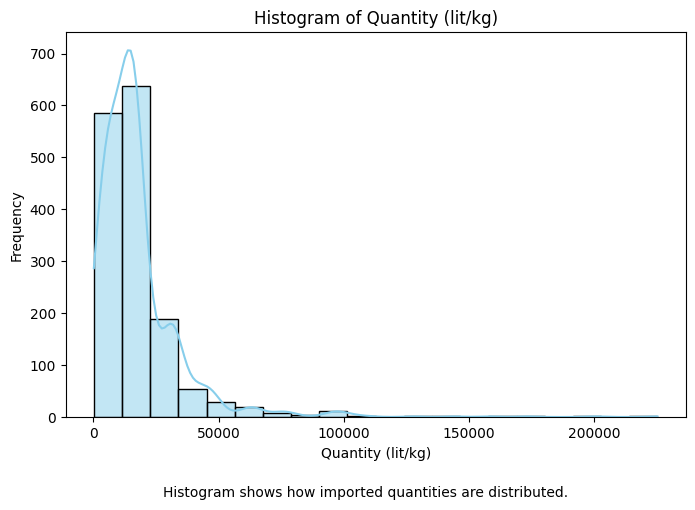

In [31]:
# ==========
# Histogram
# ==========
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity (lit/kg)'], kde=True, color='skyblue', bins=20)
plt.title("Histogram of Quantity (lit/kg)")
plt.xlabel("Quantity (lit/kg)")
plt.ylabel("Frequency")

plt.figtext(0.5, -0.05, "Histogram shows how imported quantities are distributed.", ha="center", fontsize=10)
plt.show()


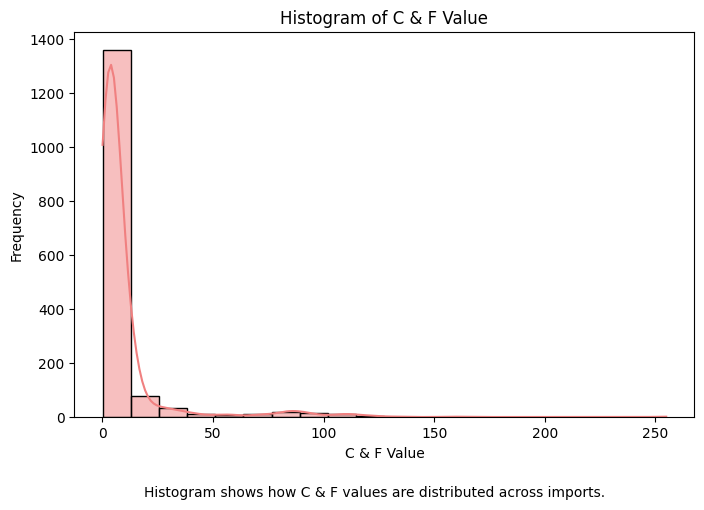

In [32]:
# =========================
# Histogram with legend
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['C & FValue'], kde=True, color='lightcoral', bins=20)
plt.title("Histogram of C & F Value")
plt.xlabel("C & F Value")
plt.ylabel("Frequency")

# Good legend/insight
plt.figtext(0.5, -0.05, "Histogram shows how C & F values are distributed across imports.", ha="center", fontsize=10)
plt.show()


count    1.545000e+03
mean     9.417707e+06
std      1.773937e+07
min      1.643000e+05
25%      3.222400e+06
50%      5.549100e+06
75%      9.361920e+06
max      2.745930e+08
Name: Total Value (Rs.), dtype: float64
Missing values: 0


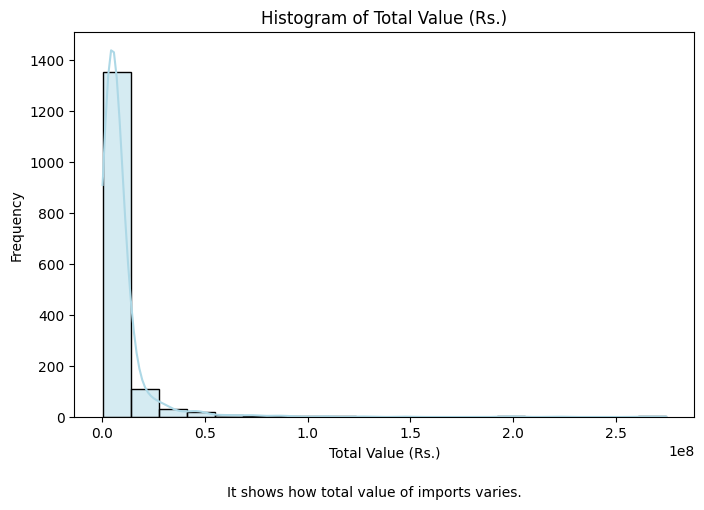

In [33]:
# Summary statistics
print(df['Total Value (Rs.)'].describe())

# Missing values
print("Missing values:", df['Total Value (Rs.)'].isnull().sum())

# =========================
# Histogram
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['Total Value (Rs.)'], kde=True, color='lightblue', bins=20)
plt.title("Histogram of Total Value (Rs.)")
plt.xlabel("Total Value (Rs.)")
plt.ylabel("Frequency")

plt.figtext(0.5, -0.05, "It shows how total value of imports varies.", ha="center", fontsize=10)
plt.show()


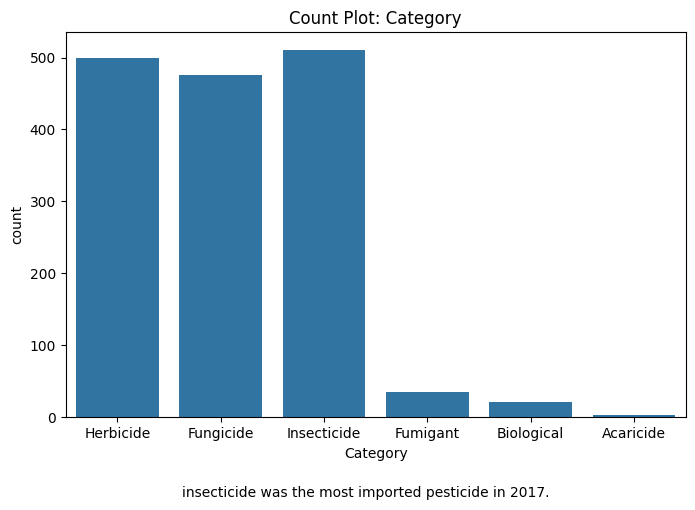

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df)
plt.title("Count Plot: Category")
plt.figtext(0.5, -0.05, "insecticide was the most imported pesticide in 2017.", ha="center", fontsize=10)

plt.show()


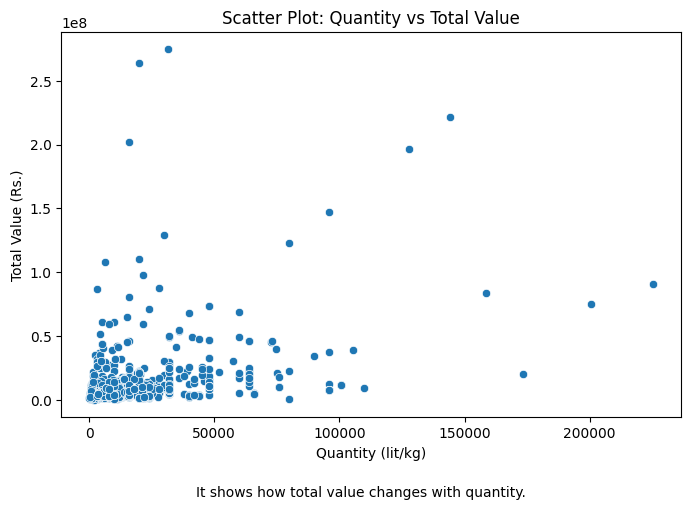

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity (lit/kg)', y='Total Value (Rs.)', data=df)
plt.title("Scatter Plot: Quantity vs Total Value")
plt.xlabel("Quantity (lit/kg)")
plt.ylabel("Total Value (Rs.)")

# Short legend/insight
plt.figtext(0.5, -0.05, "It shows how total value changes with quantity.", ha="center", fontsize=10)

plt.show()


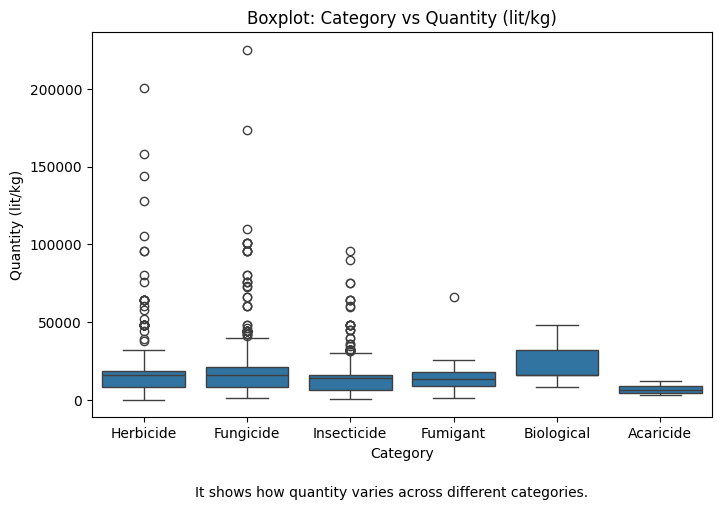

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Quantity (lit/kg)', data=df)

plt.title("Boxplot: Category vs Quantity (lit/kg)")

# Short legend/insight
plt.figtext(0.5, -0.05, "It shows how quantity varies across different categories.", ha="center", fontsize=10)

plt.show()


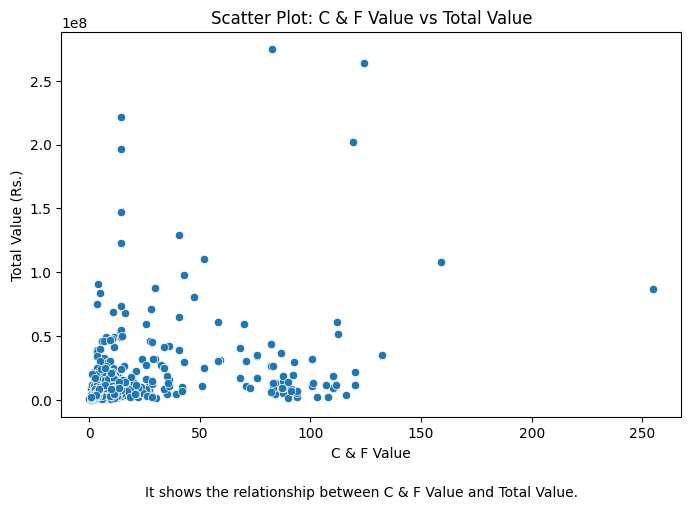

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='C & FValue', y='Total Value (Rs.)', data=df)

plt.title("Scatter Plot: C & F Value vs Total Value")
plt.xlabel("C & F Value")
plt.ylabel("Total Value (Rs.)")

# Short legend/insight
plt.figtext(0.5, -0.05, "It shows the relationship between C & F Value and Total Value.", ha="center", fontsize=10)

plt.show()


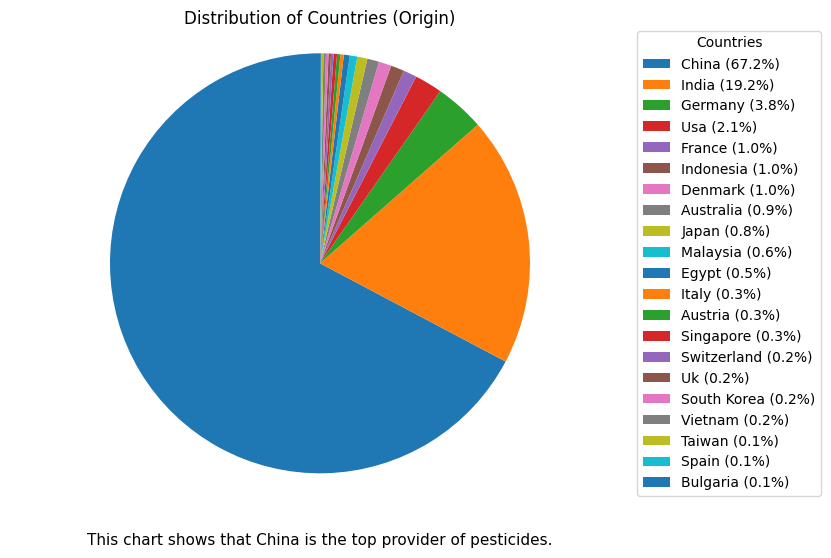

In [38]:
# Clean the country names
df['Origin_Name'] = (
    df['Origin']
    .astype(str)
    .str.strip()
    .str.title()     # Converts 'china', 'CHINA', ' China ' → 'China'
)

# Count countries
origin_counts = df['Origin_Name'].value_counts()

# Safety check
if origin_counts.empty:
    print("No countries found in Origin column — check data.")
else:
    # Calculate percentages
    percentages = 100 * origin_counts / origin_counts.sum()
    labels_with_pct = [
        f'{country} ({pct:.1f}%)'
        for country, pct in zip(origin_counts.index, percentages)
    ]

    # Top country
    top_country = origin_counts.idxmax()

    # Plot
    plt.figure(figsize=(8,6))
    plt.pie(origin_counts, startangle=90)

    plt.legend(
        labels_with_pct,
        title="Countries",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )
    plt.title("Distribution of Countries (Origin)")
    plt.axis('equal')

    plt.text(
        0.5, -0.1,
        f"This chart shows that {top_country} is the top provider of pesticides.",
        ha='center',
        va='center',
        fontsize=11,
        transform=plt.gca().transAxes
    )

    plt.show()


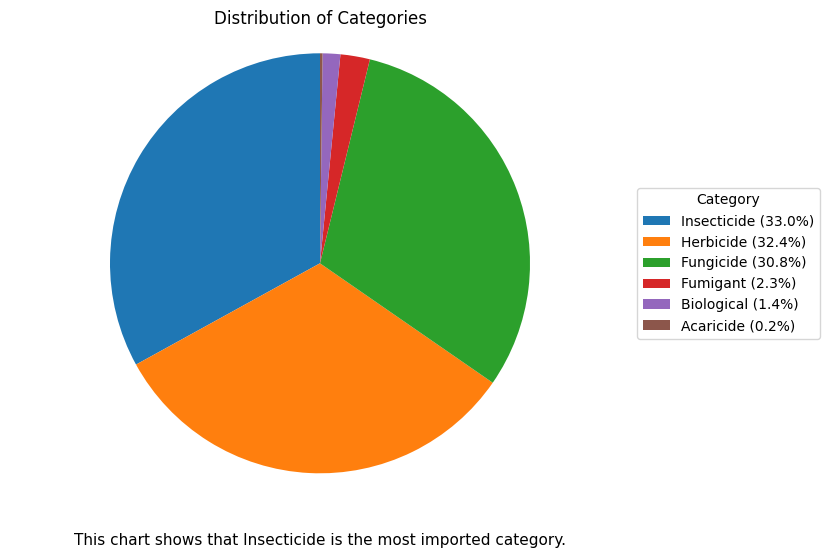

In [39]:

category_counts = df['Category'].value_counts()

# Calculate percentages
percentages = 100 * category_counts / category_counts.sum()
labels_with_pct = [f'{cat} ({pct:.1f}%)' for cat, pct in zip(category_counts.index, percentages)]

# Find the highest imported category
top_category = category_counts.idxmax()

plt.figure(figsize=(8,6))
plt.pie(category_counts, startangle=90)
plt.legend(labels_with_pct, title="Category", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Distribution of Categories")
plt.axis('equal')

plt.text(
    0.5, -0.1,
    f"This chart shows that {top_category} is the most imported category.",
    ha='center',
    va='center',
    fontsize=11,
    transform=plt.gca().transAxes
)

plt.show()


/tmp/ipython-input-1227474350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_counts.values, y=origin_counts.index, palette='viridis')


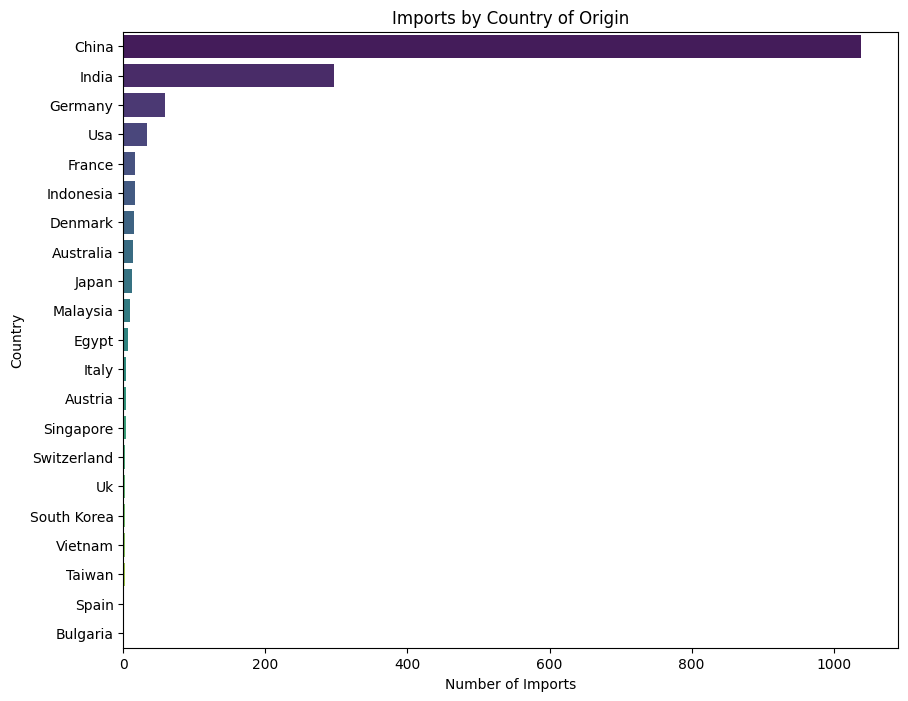

In [40]:
plt.figure(figsize=(10, 8))
# Count and sort
origin_counts = df['Origin_Name'].value_counts().sort_values(ascending=False)

sns.barplot(x=origin_counts.values, y=origin_counts.index, palette='viridis')
plt.title('Imports by Country of Origin')
plt.xlabel('Number of Imports')
plt.ylabel('Country')
plt.show()

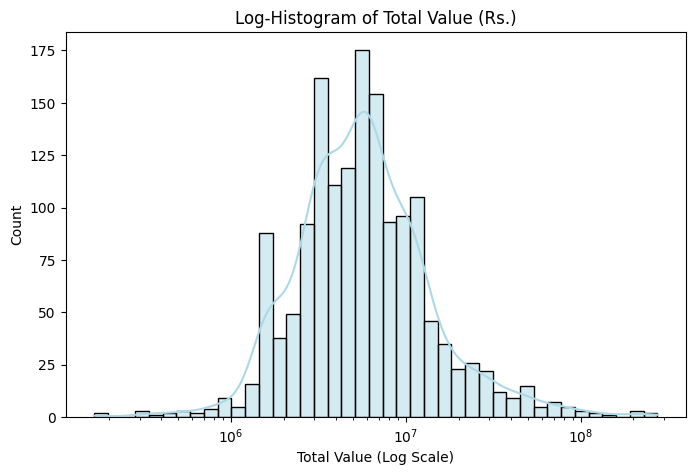

In [41]:
plt.figure(figsize=(8,5))
# Apply log scale to x-axis to normalize the view
sns.histplot(df['Total Value (Rs.)'], kde=True, log_scale=True, color='lightblue')
plt.title("Log-Histogram of Total Value (Rs.)")
plt.xlabel("Total Value (Log Scale)")
plt.show()

/tmp/ipython-input-1786351179.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_imports = df.set_index('Date').resample('M')['Total Value (Rs.)'].sum().reset_index()


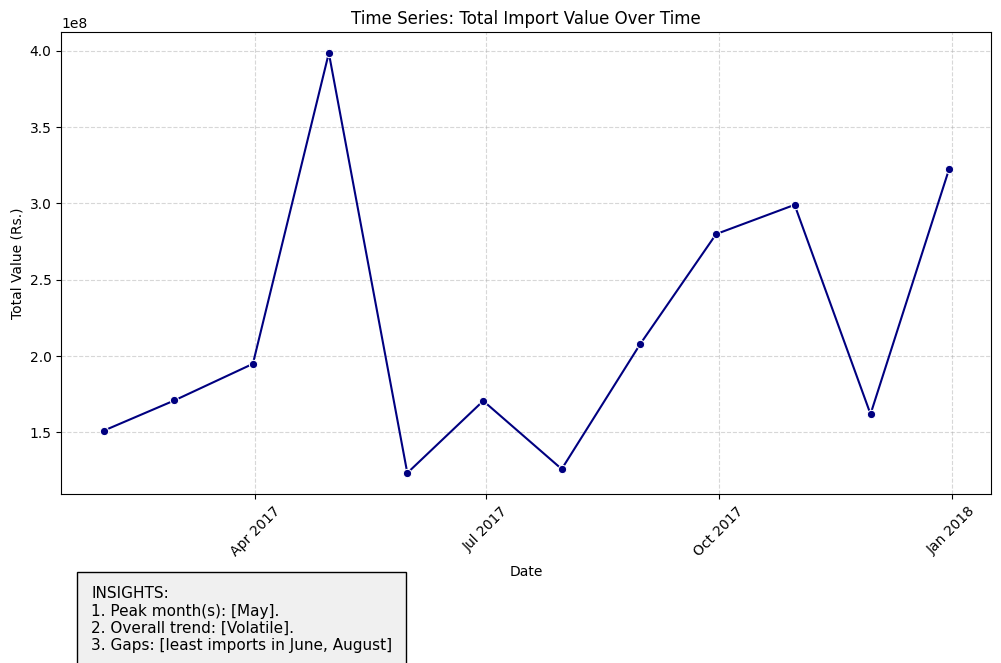

In [42]:
import matplotlib.dates as mdates

# Ensure Date format is correct
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Aggregate data by Month
# We use 'M' for month-end frequency
monthly_imports = df.set_index('Date').resample('M')['Total Value (Rs.)'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_imports, x='Date', y='Total Value (Rs.)', marker='o', color='navy')

# Formatting the x-axis to make dates readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.title('Time Series: Total Import Value Over Time')
plt.ylabel('Total Value (Rs.)')
plt.grid(True, linestyle='--', alpha=0.5)

# --- INSIGHT TEMPLATE ---
insight_text = (
    "INSIGHTS:\n"
    "1. Peak month(s): [May].\n"
    "2. Overall trend: [Volatile].\n"
    "3. Gaps: [least imports in June, August]"
)

plt.figtext(0.15, -0.15, insight_text, ha='left', fontsize=11,
            bbox=dict(facecolor='#f0f0f0', alpha=1, pad=10))

plt.show()

/tmp/ipython-input-220729605.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_firms.values, y=top_firms.index, ax=axes[0], palette='viridis', orient='h')
/tmp/ipython-input-220729605.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1], palette='magma', orient='h')


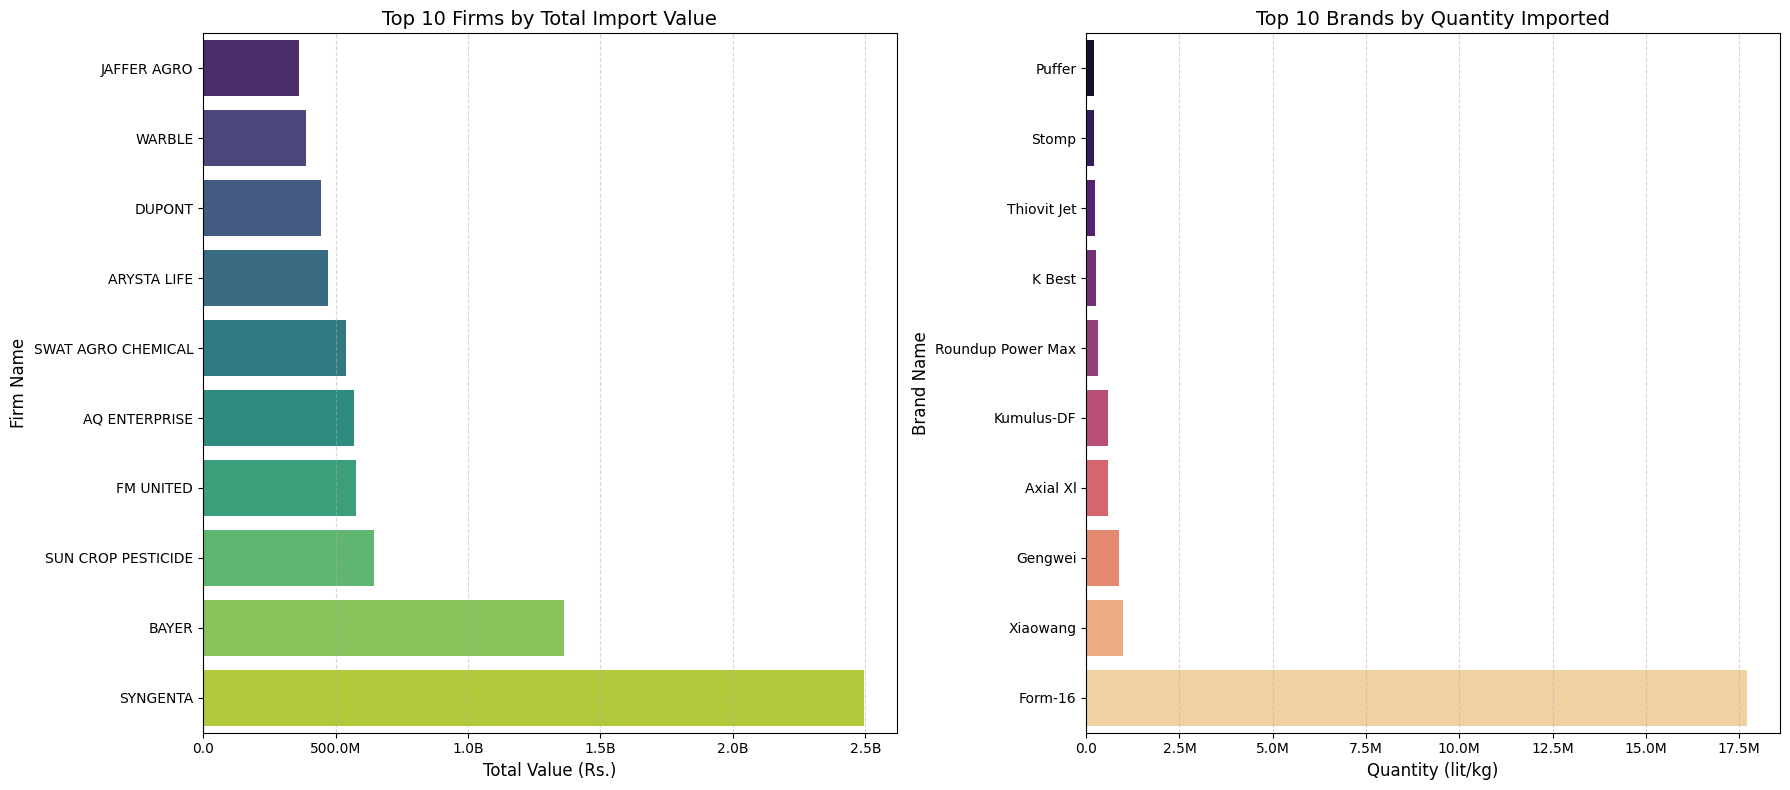

In [43]:
import matplotlib.ticker as ticker
#df['Firm Name'] = df['Firm Name'].astype(str)
#df['Brand Name'] = encoders['Brand Name'].inverse_transform(df['Brand Name'].astype(int))
# Function to format large numbers (e.g., 1,000,000 -> 1M)
def human_format(num, pos):
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return '%.1f%s' % (num, ['', 'K', 'M', 'B'][magnitude])

# Set up the canvas
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------------------------------------------------------
# Chart 1: Top 10 Firms by Value (Horizontal)
# -------------------------------------------------------
# Sort ascending so the largest bar is at the top when plotting horizontally
top_firms = df.groupby('Firm Name')['Total Value (Rs.)'].sum().nlargest(10).sort_values(ascending=True)

sns.barplot(x=top_firms.values, y=top_firms.index, ax=axes[0], palette='viridis', orient='h')

axes[0].set_title('Top 10 Firms by Total Import Value', fontsize=14)
axes[0].set_xlabel('Total Value (Rs.)', fontsize=12)
axes[0].set_ylabel('Firm Name', fontsize=12)
# Apply the readable number formatter to the X-axis
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(human_format))
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


# -------------------------------------------------------
# Chart 2: Top 10 Brands by Quantity (Horizontal)
# -------------------------------------------------------

top_brands = df.groupby('Brand Name')['Quantity (lit/kg)'].sum().nlargest(10).sort_values(ascending=True)

sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1], palette='magma', orient='h')

axes[1].set_title('Top 10 Brands by Quantity Imported', fontsize=14)
axes[1].set_xlabel('Quantity (lit/kg)', fontsize=12)
axes[1].set_ylabel('Brand Name', fontsize=12)
# Apply the readable number formatter to the X-axis
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(human_format))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

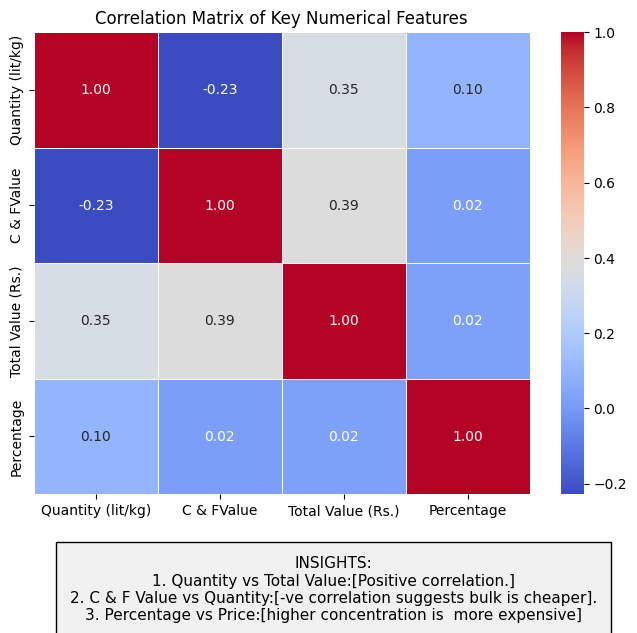

In [44]:
# Select only numeric columns for correlation
numeric_df = df[['Quantity (lit/kg)', 'C & FValue', 'Total Value (Rs.)', 'Percentage']]

plt.figure(figsize=(8, 6))
# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Numerical Features')

# --- INSIGHT TEMPLATE ---
plt.figtext(0.5, -0.1,
            "INSIGHTS:\n"
            "1. Quantity vs Total Value:[Positive correlation.]\n"
            "2. C & F Value vs Quantity:[-ve correlation suggests bulk is cheaper].\n"
            "3. Percentage vs Price:[higher concentration is  more expensive]",
            ha='center', fontsize=11, bbox=dict(facecolor='#f0f0f0', alpha=1, pad=10))

plt.show()

/tmp/ipython-input-1414164335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='C & FValue', data=df, palette='Set2')


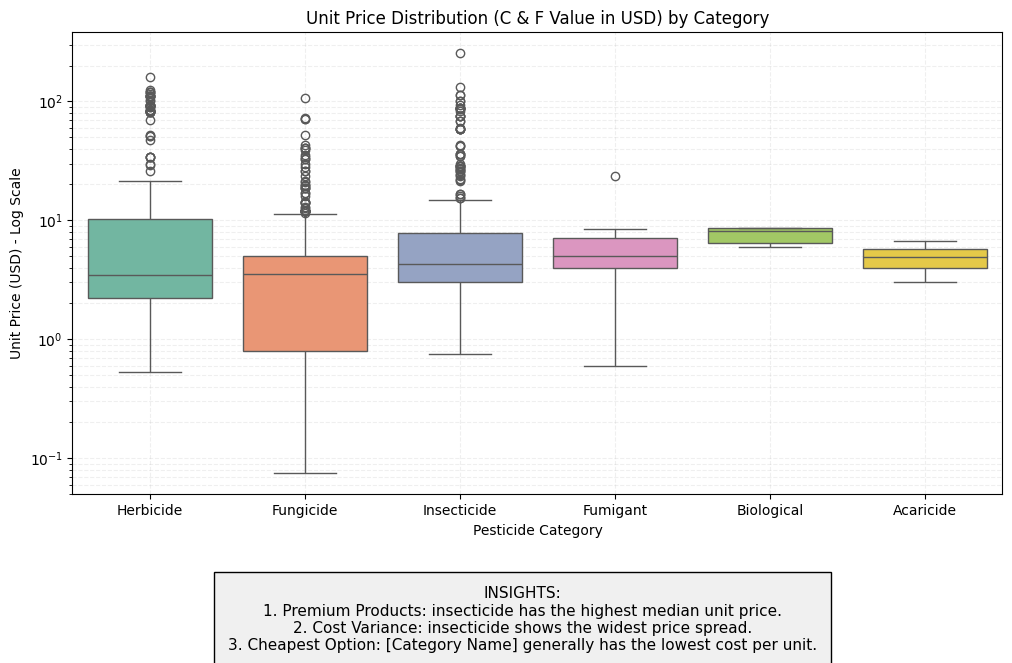

In [45]:
plt.figure(figsize=(12, 6))

# We use C & F Value as the Unit Price
# A Log Scale is applied because prices often range from very low ($1) to very high ($100+)
sns.boxplot(x='Category', y='C & FValue', data=df, palette='Set2')
plt.yscale('log')

plt.title('Unit Price Distribution (C & F Value in USD) by Category')
plt.ylabel('Unit Price (USD) - Log Scale')
plt.xlabel('Pesticide Category')
plt.grid(True, which="both", ls="--", alpha=0.2)

# --- INSIGHT TEMPLATE ---
insight_text = (
    "INSIGHTS:\n"
    "1. Premium Products: insecticide has the highest median unit price.\n"
    "2. Cost Variance: insecticide shows the widest price spread.\n"
    "3. Cheapest Option: [Category Name] generally has the lowest cost per unit."
)

plt.figtext(0.5, -0.15, insight_text, ha='center', fontsize=11,
            bbox=dict(facecolor='#f0f0f0', alpha=1, pad=10))

plt.show()

data cleaning and EDA done here for ass1 and ass2; frm here model training work has started.

In [46]:
df['C & FValue'].describe()

,C & FValue
count,1545.000000
mean,9.513596
std,19.568829
min,0.075000
25%,2.300000
50%,3.800000
75%,7.740000
max,254.880000


In [47]:
def detect_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]


In [48]:
numeric_cols = ["Quantity (lit/kg)", "C & FValue"]
for col in numeric_cols:
    print(col, len(detect_outliers_iqr(col)))


Quantity (lit/kg) 125
C & FValue 141


In [49]:
df['Total Value (Rs.)'].describe()

,Total Value (Rs.)
count,1.545000e+03
mean,9.417707e+06
std,1.773937e+07
min,1.643000e+05
25%,3.222400e+06
50%,5.549100e+06
75%,9.361920e+06
max,2.745930e+08


In [50]:
def cap_outliers(df, col):
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)
    return df

for col in numeric_cols:
    df = cap_outliers(df, col)


In [51]:
# ---- Outlier Capping (Winsorization) ----

numeric_cols = ["Quantity (lit/kg)", "C & FValue"]

def cap_outliers(df, col, lower_q=0.01, upper_q=0.99):
    lower = df[col].quantile(lower_q)
    upper = df[col].quantile(upper_q)
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

for col in numeric_cols:
    df = cap_outliers(df, col)


In [52]:
for col in numeric_cols:
    print(col, "Capped Min:", df[col].min(), "Capped Max:", df[col].max())


Quantity (lit/kg) Capped Min: 800.0 Capped Max: 96000.0
C & FValue Capped Min: 0.6514800000000001 Capped Max: 107.36851199999994


In [53]:
df.nlargest(30, "Percentage")

,Date,Job No.,Firm Name,Brand Name,Comman Name,Quantity (lit/kg),C & FValue,Total Value (Rs.),Origin,Reg. No.,PSI,Category,Percentage,Type,Origin_Name
279,NaT,CU17019428,NAFEES ENTERPRISE,Form-16,S-metolachlor,23000.0,5.77000,14067260.00,China,R-5761,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
290,NaT,CU17029638,NAFEES ENTERPRISE,Form-16,S-metolachlor,16000.0,5.78000,9802880.00,China,R-6366,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
395,2017-07-04,C/S/PK/170072/17,PAK PANSY,Form-16,S-metolachlor,16000.0,6.80000,11532800.00,China,R-6342,NMCI,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
425,NaT,CU17039846,WELCOME AGRO,Form-16,S-metolachlor,16000.0,5.80000,9836800.00,China,R-6994,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
446,NaT,CU17039850,WELCOME AGRO,Form-16,S-metolachlor,16000.0,5.80000,9836800.00,China,R-6994,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
617,NaT,CU170310065,NUCHEM,Form-16,S-metolachlor,16000.0,5.75000,9752000.00,China,R-7145,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
727,NaT,CU170510407,SESSA FARM CHEMICAL,Form-16,S-metolachlor,64000.0,6.82000,46266880.00,China,R-7190,CU,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
1034,NaT,C/PIC/PBN17003,PLANT 4 LIFE,Form-16,S-metolachlor,4000.0,5.70000,2416800.00,China,R-7241,NMCI,Herbicide,960.0,EMULSIFIABLE CONCENTRATE,China
1132,NaT,CU170810928,ICI,Form-16,S-metolachlor,16000.0,6.10000,10345600.00,China,R-6448,CU,Herbicide,960.0,GRAMS PER LITRE,China
351,2017-10-04,9030/17LW,SYNGENTA,Primextra Gold,S-Metolachlor + Atrazine,16000.0,7.60000,12889600.00,France,R-529,CU,Herbicide,720.0,SOLUBLE CONCENTRATE,France


In [54]:
df.nlargest(20, "C & FValue")


,Date,Job No.,Firm Name,Brand Name,Comman Name,Quantity (lit/kg),C & FValue,Total Value (Rs.),Origin,Reg. No.,PSI,Category,Percentage,Type,Origin_Name
62,NaT,FW16112531,SWAT AGRO CHEMICAL,Clio,Topramezone,800.0,107.368512,9328000.0,Germany,R-1584,BALTIC,Herbicide,336.0,GRAMS PER LITRE,Germany
196,2017-09-03,FW17012577,SWAT AGRO CHEMICAL,Clio,Topramezone,800.0,107.368512,9328000.0,Germany,R-1584,BALTIC,Herbicide,336.0,GRAMS PER LITRE,Germany
197,2017-09-03,FW17022584,SWAT AGRO CHEMICAL,Clio,Topramezone,800.0,107.368512,9328000.0,Germany,R-1584,BALTIC,Herbicide,336.0,GRAMS PER LITRE,Germany
359,NaT,BTIN/1272/2017,SYNGENTA,Actara,Thiamethoxam,2500.0,107.368512,35022400.0,India,R-496,BALTIC,Insecticide,70.0,WATER SOLUBLE POWDER,India
520,2017-04-05,CU17029597,DUPONT,Ferterra,Chlorantraniliprole,3200.0,107.368512,86455296.0,USA,R-875,CU,Insecticide,0.4,GRAMS PER LITRE,Usa
533,NaT,9106/17RE,BAYER,Belt,Flubendiamide,4300.0,107.368512,51277500.0,Germany,R-608,ICI,Insecticide,480.0,GRAMS PER LITRE SOLUBLE CONCENTRATE,Germany
674,NaT,C/PK/AL17018,MI,Orcus,Halosulfuron Methyl,800.0,107.368512,3683394.0,China,R-2360,NMCI,Herbicide,75.0,WDG,China
695,2017-08-06,9024/17Re,BAYER,Sunstar Gold,Ethoxysulfuron,898.0,107.368512,11422560.0,Germany,R-639,ICI,Herbicide,60.0,WEIGHTABLE GRANULERS,Germany
703,NaT,RE-9274/17,BAYER,Sunstar Gold,Ethoxysulfuron,1690.0,107.368512,21496800.0,Germany,R-639,ICI,Herbicide,60.0,WEIGHTABLE GRANULERS,Germany
706,NaT,BTIN/1317/2017,SYNGENTA,Virtako,Thiamethoxam + Chlorantraniliprole,5150.0,107.368512,61140800.0,India,R-894,ICI,Insecticide,40.0,WEIGHTABLE GRANULERS,India


In [55]:
df['Percentage'].describe()

,Percentage
count,1545.000000
mean,87.730822
std,135.172605
min,0.020000
25%,25.000000
50%,55.000000
75%,77.000000
max,960.000000


In [56]:
df["Percentage"] = df["Percentage"].apply(
    lambda x: x/100 if x > 100 else x
)


converted the non-percentage values into percentage

In [57]:
df["Percentage"].nlargest(30)
#df["Percentage"].describe()


,Percentage
233,100.0
316,100.0
987,100.0
23,98.0
223,98.0
382,98.0
443,98.0
644,98.0
699,98.0
979,98.0


In [58]:
df['Total Value (Rs.)']=df['C & FValue']*df['Quantity (lit/kg)']*106

In [59]:
df['Total Value (Rs.)'].describe()

,Total Value (Rs.)
count,1.545000e+03
mean,9.183272e+06
std,1.597639e+07
min,1.643000e+05
25%,3.222400e+06
50%,5.596800e+06
75%,9.349200e+06
max,2.745930e+08


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['C & FValue', 'Quantity (lit/kg)', 'Total Value (Rs.)']] = scaler.fit_transform(df[['C & FValue', 'Quantity (lit/kg)', 'Total Value (Rs.)']])


the cleaning for the model training is completed and model training begins here

In [61]:
df.head()

,Date,Job No.,Firm Name,Brand Name,Comman Name,Quantity (lit/kg),C & FValue,Total Value (Rs.),Origin,Reg. No.,PSI,Category,Percentage,Type,Origin_Name
0,2017-02-01,C/PK/QC16015,EXIN CHEMICAL,Xiaowang,Mesotrione + Atrazine,-0.090862,-0.332827,-0.224558,China,R-1912,NMCI,Herbicide,55.0,SOLUBLE CONCENTRATE,China
1,2017-02-01,C/S/PK/170059/16,NEW AGRI CARE,Deft,Metsulfuron Methyl,-0.984545,-0.328953,-0.530256,China,R-908,NMCI,Herbicide,10.0,WAIGHTABLE POWDER,China
2,2017-02-01,CU16119148,TARA IMPERIAL,Form-16,Glyphosate,0.930491,-0.416959,-0.196949,China,R-6945,CU,Herbicide,41.0,SOLUBLE LIQUID,China
3,2017-02-01,CU16119110,TARA IMPERIAL,Form-16,Metalaxyl + Mancozeb,-0.154696,-0.316222,-0.216594,China,R-4982,CU,Fungicide,72.0,WAIGHTABLE POWDER,China
4,2017-03-01,PK-130617/16,SUN CROP PESTICIDE,Truce Xtra,Mesotrione + Atrazine,-1.048379,-0.045006,-0.518575,China,R-1983,NMCI,Herbicide,88.8,WEIGHTABLE GRANULERS,China


In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report

# 1. Setup Data
cols_to_drop = ['Date', 'Job No.', 'Reg. No.', 'PSI', 'Brand Name']
X = df.drop(columns=['Category'] + cols_to_drop, errors='ignore')
y = df['Category']

# CRITICAL STEP FOR XGBOOST: Encode text labels (Herbicide, etc.) to Integers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Define Feature Groups
# Using 'char_wb' is powerful for chemicals because it learns sub-structures
# (e.g., it learns that "methrin" in "Cypermethrin" usually means Insecticide)
nlp_features = 'Comman Name'
categorical_features = ['Firm Name', 'Type', 'Origin_Name']
numeric_features = ['Percentage', 'Total Value (Rs.)', 'Quantity (lit/kg)']

# 3. Create the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('txt', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5)), nlp_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# 4. Build the XGBoost Pipeline
# Colab usually runs XGBoost 2.0+, which uses the 'device' parameter
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        # --- GPU Parameters ---
        device='cuda',          # <--- CRITICAL: Tells XGBoost to use the GPU
        tree_method='hist',     # <--- Best tree method for GPU (faster than default)

        # --- Model Parameters ---
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softmax',
        num_class=len(le.classes_),
        n_jobs=-1,              # Still useful for data loading/preprocessing
        random_state=42
    ))
])

# 5. Train and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Training XGBoost model...")
model_pipeline.fit(X_train, y_train)

print("Evaluating...")
preds = model_pipeline.predict(X_test)

# Inverse transform labels to see the actual names in the report
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(preds)))


Training XGBoost model...
Evaluating...
              precision    recall  f1-score   support

   Acaricide       0.00      0.00      0.00         1
  Biological       1.00      1.00      1.00         2
    Fumigant       0.88      1.00      0.93         7
   Fungicide       1.00      0.94      0.97        96
   Herbicide       1.00      1.00      1.00        99
 Insecticide       0.95      1.00      0.97       104

    accuracy                           0.98       309
   macro avg       0.80      0.82      0.81       309
weighted avg       0.98      0.98      0.98       309



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [06:11:32] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bein

Model and Encoder saved successfully.


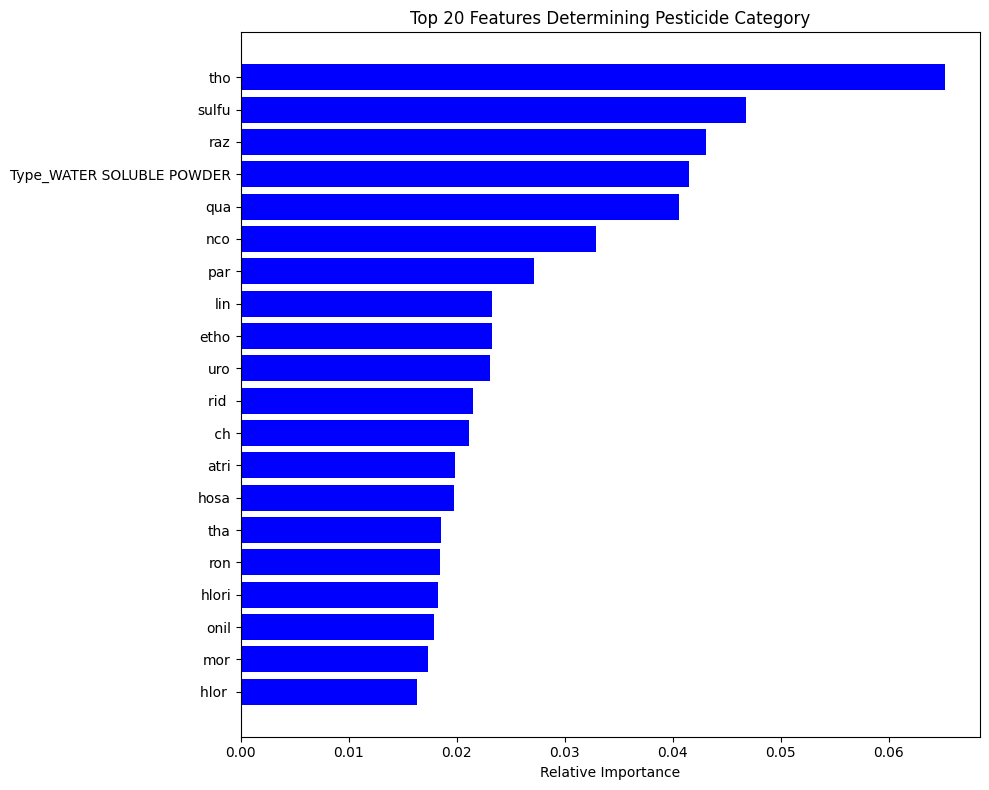

In [63]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SAVE THE MODEL ---
# We save the whole pipeline (Preprocessing + XGBoost)
# This file will be about 1-5MB
joblib.dump(model_pipeline, 'pesticide_prediction_model.joblib')
joblib.dump(le, 'label_encoder.joblib')
print("Model and Encoder saved successfully.")

# --- 2. RELOAD (How to use it later) ---
# loaded_model = joblib.load('pesticide_prediction_model.joblib')
# loaded_le = joblib.load('label_encoder.joblib')
# prediction = loaded_model.predict(new_data)
# real_name = loaded_le.inverse_transform(prediction)


# --- 3. EXPLAINABILITY (What did the model learn?) ---
# It's tricky to get feature names from a Pipeline, here is the helper code:

# A. Get the XGBoost model from the pipeline
xgb_model = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

# B. Get feature names from the TF-IDF vectorizer
tfidf_names = preprocessor.named_transformers_['txt'].get_feature_names_out()

# C. Get feature names from OneHotEncoder
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out()

# D. Combine all names (Order must match the pipeline order: Txt -> Cat -> Num)
all_feature_names = np.r_[tfidf_names, cat_names, ['Percentage', 'Total Value (Rs.)', 'Quantity (lit/kg)']]

# E. Get Feature Importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:] # Top 20 features

# F. Plot
plt.figure(figsize=(10, 8))
plt.title('Top 20 Features Determining Pesticide Category')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [64]:
# Example input (replace with real data)
test_sample = {
    'Comman Name': "Imidacloprid + Tebuconazole",
    'Firm Name': "Pak China Chemicals",
    'Type': "WAIGHTABLE POWDER",
    'Origin_Name': "China",
    'Percentage': 10,
    'Total Value (Rs.)': 130000,
    'Quantity (lit/kg)': 20
}

# Convert to DataFrame
test_df = pd.DataFrame([test_sample])

# Predict
loaded_model = joblib.load("pesticide_prediction_model.joblib")
loaded_le = joblib.load("label_encoder.joblib")

pred = loaded_model.predict(test_df)[0]
category = loaded_le.inverse_transform([pred])[0]

print("Predicted Category:", category)


Predicted Category: Insecticide


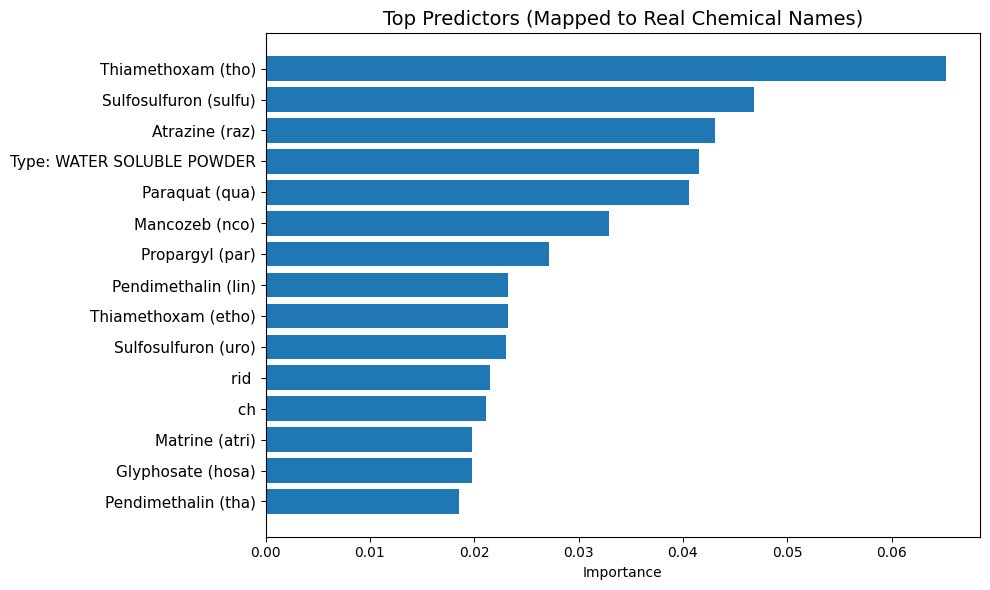

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# This function finds the real word that generated the "random letters"
def get_real_name(ngram, text_column):
    # Search for the ngram (e.g., 'hosa') in your data
    matches = text_column[text_column.str.contains(ngram, case=False, na='')]
    if len(matches) > 0:
        # Find the most common full word containing this ngram
        # e.g., if 'hosa' is found in 'Glyphosate' 500 times, return 'Glyphosate'
        all_text = ' '.join(matches.astype(str))
        words = all_text.split()
        containing_words = [w for w in words if ngram in w.lower()]
        if containing_words:
            # Return the most frequent containing word
            return max(set(containing_words), key=containing_words.count)
    return ngram # Fallback if no matching word is found

# 1. Get the Model components (from your already trained pipeline)
# Assuming 'model_pipeline' and 'X' (the features dataframe) are defined from the previous cell.
xgb_model = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

# 2. Get all feature names
txt_names = preprocessor.named_transformers_['txt'].get_feature_names_out()
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out()
num_names = ['Percentage', 'Total Value', 'Quantity']

# Combine them strictly in order
all_names = np.r_[txt_names, cat_names, num_names]

# 3. Get Top 15 Features
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-15:]

# 4. Generate Clean Labels (The Magic Step)
clean_labels = []
for i in indices:
    raw_name = all_names[i]

    # Check if it's one of those weird text features
    if raw_name in txt_names:
        # Find the real word from your DataFrame 'X'
        real_word = get_real_name(raw_name, X['Comman Name'])
        # Clean up the display slightly: if the real word is the same as the ngram, skip the parenthesis
        if real_word.lower() == raw_name:
             clean_labels.append(real_word)
        else:
            clean_labels.append(f"{real_word} ({raw_name})") # Shows "Glyphosate (hosa)"
    else:
        # It's a category like "Firm Name_Syngenta"
        # Extract the value from the OneHotEncoder names
        clean_name = raw_name.split('__')[-1].split('_')[-1]

        # Make sure the category name is clear (e.g., 'firm name' vs 'origin')
        if 'Firm Name' in raw_name:
            clean_name = f"Firm: {clean_name}"
        elif 'Origin' in raw_name:
            clean_name = f"Origin: {clean_name}"
        elif 'Type' in raw_name:
            clean_name = f"Type: {clean_name}"

        clean_labels.append(clean_name)


# 5. Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='#1f77b4')
plt.yticks(range(len(indices)), clean_labels, fontsize=11)
plt.title('Top Predictors (Mapped to Real Chemical Names)', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

now im working to make some gui

In [91]:
!pip install gradio joblib


In [2]:
from google.colab import files
files.upload() # A dialog box will pop up to select the file

Saving label_encoder.joblib to label_encoder.joblib
Saving pesticide_prediction_model.joblib to pesticide_prediction_model.joblib


{'label_encoder.joblib': b'\x80\x04\x95\x12\x01\x00\x00\x00\x00\x00\x00\x8c\x1csklearn.preprocessing._label\x94\x8c\x0cLabelEncoder\x94\x93\x94)\x81\x94}\x94(\x8c\x08classes_\x94\x8c\x13joblib.numpy_pickle\x94\x8c\x11NumpyArrayWrapper\x94\x93\x94)\x81\x94}\x94(\x8c\x08subclass\x94\x8c\x05numpy\x94\x8c\x07ndarray\x94\x93\x94\x8c\x05shape\x94K\x06\x85\x94\x8c\x05order\x94\x8c\x01C\x94\x8c\x05dtype\x94h\x0c\x8c\x05dtype\x94\x93\x94\x8c\x02O8\x94\x89\x88\x87\x94R\x94(K\x03\x8c\x01|\x94NNNJ\xff\xff\xff\xffJ\xff\xff\xff\xffK?t\x94b\x8c\nallow_mmap\x94\x89\x8c\x1bnumpy_array_alignment_bytes\x94K\x10ub\x80\x05\x95\xd4\x00\x00\x00\x00\x00\x00\x00\x8c\x16numpy._core.multiarray\x94\x8c\x0c_reconstruct\x94\x93\x94\x8c\x05numpy\x94\x8c\x07ndarray\x94\x93\x94K\x00\x85\x94C\x01b\x94\x87\x94R\x94(K\x01K\x06\x85\x94h\x03\x8c\x05dtype\x94\x93\x94\x8c\x02O8\x94\x89\x88\x87\x94R\x94(K\x03\x8c\x01|\x94NNNJ\xff\xff\xff\xffJ\xff\xff\xff\xffK?t\x94b\x89]\x94(\x8c\tAcaricide\x94\x8c\nBiological\x94\x8c\x08Fumi

In [3]:
import gradio as gr
import pandas as pd
import joblib

# Load model
model = joblib.load("pesticide_prediction_model.joblib")
label_enc = joblib.load("label_encoder.joblib")

def predict(common, firm, type_, origin, percentage, total_value, quantity):
    row = pd.DataFrame([{
        "Comman Name": common,
        "Firm Name": firm,
        "Type": type_,
        "Origin_Name": origin,
        "Percentage": percentage,
        "Total Value (Rs.)": total_value,
        "Quantity (lit/kg)": quantity,
    }])

    pred = model.predict(row)[0]
    category = label_enc.inverse_transform([pred])[0]
    return f"Predicted Category: {category}"


with gr.Blocks() as demo:

    gr.Markdown(
        """
        # 🌿 **Pesticide Category Prediction System**
        ### Predict the regulatory category of pesticide imports using Machine Learning
        ---
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🧪 Chemical Information")
            common = gr.Textbox(label="Common Name")
            type_ = gr.Textbox(label="Type (e.g., Soluble liquid)")

            gr.Markdown("### 🏭 Company Details")
            firm = gr.Textbox(label="Firm Name")
            origin = gr.Textbox(label="Origin Name(country)")

        with gr.Column():
            gr.Markdown("### 📦 Import Quantities")
            percentage = gr.Number(label="Percentage (%)")
            total_value = gr.Number(label="Total Value (Rs.)")
            quantity = gr.Number(label="Quantity (lit/kg)")

    with gr.Row():
        predict_btn = gr.Button("🔍 Predict Category")

    output = gr.Textbox(label="Prediction Result")

    predict_btn.click(
        fn=predict,
        inputs=[common, firm, type_, origin, percentage, total_value, quantity],
        outputs=output
    )

demo.launch()


/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:34:04] WARNING: /workspace/src/gbm/gbtree.cc:377: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:34:04] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:34:04] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2b06bb4020db975d33.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
